<a href="https://colab.research.google.com/github/awickland17/hello/blob/Math-in-the-city/nb3_how_to_train_your_model_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1: How to Train Your Model

In Jupyter Notebook 2: Matrices, we saw that images are stored digitally as multidimensional arrays. Another name for a multidimensional array is a *tensor*. This project will introduce you to TensorFlow, a machine learning programming library created by Google and used by many companies for creating and training models. It’s named after tensors, which are the primary object of coding with TensorFlow.

Let's check to see if you have Tensorflow installed, and install it if necessary.

In [1]:
try:
    import tensorflow as tf
    print("\nTensorflow is installed.")
except ImportError as e:
    print("Tensorflow not installed, please install it using 'pip install tensorflow.")
    pass


TensorFlow is installed.


In [ ]:
# Only run this cell if you need to install tensorflow.
pip install tensorflow # install tensorflow

### **Problem 1**
It’s important to appreciate the computational efficiency of programming with tensors. Let’s work through an example that illustrates this. In the two code cells below, compute the element-wise product of two vectors. I provided you with the code for using a TensorFlow command. In the code cell below that, perform the same computation using a for loop and the multiplication operation `*`. *Hint:* You should use the command `product = np.zeros(size)` to initialize a vector for your for loop.

In [12]:
import numpy as np
import tensorflow as tf
import time

size = (50000,)
u = tf.random.uniform(size)
v = tf.random.uniform(size)

start_time = time.perf_counter()
tf.math.multiply(u, v)
end_time = time.perf_counter()
execution_time = end_time - start_time

print(f"Execution time: {execution_time} seconds")

Execution time: 0.00039018700010728935 seconds


In [33]:
import numpy as np
import tensorflow as tf
import time

##Set tensor size
size = (50000,)

##Make some random tensors
u = tf.random.uniform(size)
v = tf.random.uniform(size)

##Time the multiplication
start_time = time.perf_counter()
tf.multiply(u, v)  ##Element-wise multiplication
end_time = time.perf_counter()
execution_time = end_time - start_time

print(f"Execution time: {execution_time} seconds")

Execution time: 0.0010175229999731528 seconds


## Tensorflow

Many of the array operations and functions in Tensorflow should feel familiar to NumPy, however some basic operations require us to use TensorFlow functions.

### **Problem 2**

Use the commands `tf.constant`, `tf.matmul`, `tf.scalar_mul`, and `tf.add` to define two $2\times 2$ matrices $A$ and $B$ and compute $AB+3B$.

In [21]:
import numpy as np
import tensorflow as tf

A = tf.constant([[1, 2], [3, 4]])
B = tf.constant([[5, 6], [7, 8]])

result = tf.add(tf.matmul(A, B), tf.scalar_mul(3, B))

print(result)

tf.Tensor(
[[34 40]
 [64 74]], shape=(2, 2), dtype=int32)


### **Problem 3**

Print the entry in the first row and second column of the tensor $A$ you defined in the previous problem. Describe the output in a sentence in a comment or Markdown cell below your code.

In [32]:
import numpy as np
import tensorflow as tf

##Define the constant tensor A
A = tf.constant([[1, 2], [3, 4]])

##Print first entry in A (first row)
print(A[0:1])

##Print the second column of A
print(A[:, 1])

##Print the entry in the first row and second column of A
print(A[0, 1])  ##Output: 2

###The entry in the first row and second column of tensor A is 2. This corresponds to the value at position (0, 1) in the tensor.

tf.Tensor([[1 2]], shape=(1, 2), dtype=int32)
tf.Tensor([2 4], shape=(2,), dtype=int32)
tf.Tensor(2, shape=(), dtype=int32)


Sometimes it's convenient to convert tensor objects to NumPy arrays and vice versa. Let's see how this is done below.

In [31]:
print(A.numpy()) # convert tensor to numpy array

A_r1 = A.numpy()[0] # first row of A as numpy array
A_r1 = tf.constant(A_r1) # convert numpy array to tensor

print(A_r1) # convert numpy array to tensor


[[1 2]
 [3 4]]
tf.Tensor([1 2], shape=(2,), dtype=int32)


### **Problem 4**

Print out the tensor $B$ as a NumPy array.

In [30]:
import numpy as np
import tensorflow as tf

##Define the constant tensor B
B=tf.constant([[5,6],[7,8]])

##Print tensor B as a NumPy array
print(B.numpy())

[[5 6]
 [7 8]]


## MNIST Dataset

Now let's load the MNIST dataset, which contains 70,000 samples of handwritten digits. This data is conveniently included in TensorFlow.

In [ ]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data() # load dataset and split into training and testing sets

### **Problem 5**

Display the first image. What is the image? Use Python and the `train_labels` to print a message stating the digit in the image.  *Tip: Refer to Jupyter Notebook 2 if you need to review how to display an image.*

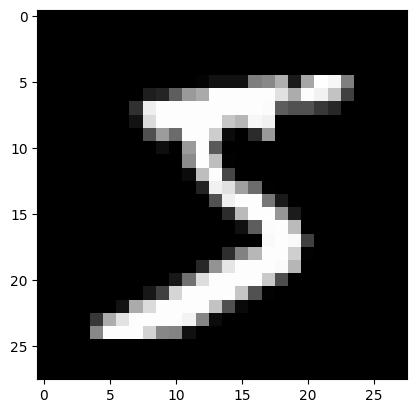

In [37]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

##Load the MNIST dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

##Display the first image
plt.imshow(train_images[0], cmap='gray')
plt.show()

###It looks like the image is a handwritten 5


### Preparing the Data

Computer processors comprise many transistors, which are essentially on/off switches. When we say computers work in binary, really we are referring to these transistors. For the most part, in all of our computations we will store float values as `float32`, which means each number is represented by `32` transistors (or bits if we want to refer to the binary representation).

Computers are generally more efficient working with float values between 0 and 1. Let's explore why.

### **Problem 6**

1. By either computing yourself, or doing an internet search, determine how many floating point numbers are there in a 32-bit system. What about a normalized 32-bit system?

2. By either computing yourself, or doing an internet search, determine the decimal precision of a 32-bit floating point number and a 32-bit floating point number in the range $0$ to $1$.

Write your answers in the Markdown cell below.

1. In a 32-bit system, there are 4,294,967,296 possible floating point numbers. In a normalized system, this reduces slightly to 4,294,967,295 values.
2. A 32-bit float has a decimal precision of about 7 digits. For numbers in the range of 0-1, the precision remains around 7 digits but improves for smaller values.

### **Problem 7**

Normalize the training and testing datasets and use the `tf.reshape` command to reshape the images to be arrays of size `(784,)`.

In [39]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

##Load the MNIST dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

##Normalize the training and testing datasets
train_images = train_images / 255.0
test_images = test_images / 255.0

##Reshape the images to size (784,)
train_images = tf.reshape(train_images, (-1, 784))
test_images = tf.reshape(test_images, (-1, 784))

##Print the shapes of the reshaped datasets
print(train_images.shape)
print(test_images.shape)

(60000, 784)
(10000, 784)


### **Problem 8**

As we discussed in class, we need to convert the labels to categorical data. Fortunately, there is a command for this: `tf.keras.utils.to_categorical`.

Convert the training and testing labels to categorical data.

In [40]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

##Load the MNIST dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

##Normalize the training and testing datasets
train_images = train_images / 255.0
test_images = test_images / 255.0

##Reshape the images to size (784,)
train_images = tf.reshape(train_images, (-1, 784))
test_images = tf.reshape(test_images, (-1, 784))

##Convert labels to categorical data
train_labels = tf.keras.utils.to_categorical(train_labels, num_classes=10)
test_labels = tf.keras.utils.to_categorical(test_labels, num_classes=10)

##Print the shapes of the categorical labels
print(train_labels.shape)
print(test_labels.shape)

(60000, 10)
(10000, 10)


### Initializing and Training Our Model

Defining a feedforward neural network using Tensorflow takes just a few lines of code.

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(784,)),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

Now we should specify our loss function and *optimizer*. The optimizer is our method for training--we'll discuss more methods in the future. For now, let's use stochastic gradient descent with `learning_rate=0.01`.

In [ ]:
loss_function = tf.keras.losses.MSE
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)

model.compile(optimizer=optimizer, loss=loss_function, metrics=['accuracy']) # initialize model weights and compile model


### **Problem 9**

Apply the model to the training data by running `model(train_images)`--define this as `pred_labels`. Then compute and print `loss_function(train_labels, pred_labels)`.

In [46]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

##Load the MNIST dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

##Normalize the training and testing datasets
train_images = train_images / 255.0
test_images = test_images / 255.0

##Reshape the images to size (784,)
train_images = tf.reshape(train_images, (-1, 784))
test_images = tf.reshape(test_images, (-1, 784))

##Convert labels to categorical data
train_labels = tf.keras.utils.to_categorical(train_labels, num_classes=10)
test_labels = tf.keras.utils.to_categorical(test_labels, num_classes=10)

##Define a simple model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(10, activation='softmax')
])

##Compile the model with a loss function and optimizer
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

##Apply the model to the training data
pred_labels = model(train_images)

##Compute and print the loss
loss = model.evaluate(train_images, train_labels)
print(f"Loss: {loss}")

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.0985 - loss: 2.3094
Loss: [2.309546709060669, 0.09928333014249802]


Now let's train our model:

In [47]:
model.fit(train_images,
          train_labels,
          epochs=5,
          batch_size=32) # train model on training data for 5 epochs with batch size of 32

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8787 - loss: 0.4298
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9634 - loss: 0.1240
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9754 - loss: 0.0811
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9827 - loss: 0.0572
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9866 - loss: 0.0432


### **Problem 10**
Complete the following tasks:

1. Load the Fashion MNIST dataset using the command `tf.keras.datasets.fashion_mnist.load_data()`
2. Display the first 5 images and print their labels.
3. Prepare the training and testing data. That is, normalize and reshape the images and convert the labels to categorical data.
4. Define and train a model with $784\times 128\times 64\times 32\times 10$ architecture with the ReLU activation function in every layer except the last. For the final layer, use softmax for the activation function. Use stochastic gradient descent to train the model and mean squared error for its loss function. Train until your model has at least $90\%$ accuracy on the training data.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


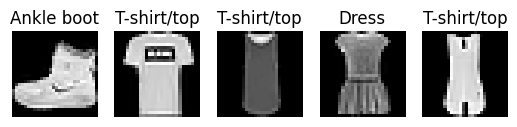

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.4530 - loss: 0.0686
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8037 - loss: 0.0294
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8289 - loss: 0.0252
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8410 - loss: 0.0233
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8462 - loss: 0.0226
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8545 - loss: 0.0216
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8590 - loss: 0.0208
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8613 - loss: 0.0205
Epoch 9/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8664 - loss: 0.0197
Epoch 10/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8691 - loss: 0.0194
Epoch 11/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8713 - loss: 0.0190
Epoch 12/50
1875/1875 ━━━━━━━━━━━━━━━

In [48]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

##Load the Fashion MNIST dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

##Class names for the Fashion MNIST dataset
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

##Display the first 5 images and print their labels
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(class_names[train_labels[i]])
    plt.axis('off')
plt.show()

##Normalize and reshape the training and testing datasets
train_images = train_images / 255.0
test_images = test_images / 255.0
train_images = tf.reshape(train_images, (-1, 784))
test_images = tf.reshape(test_images, (-1, 784))

##Convert labels to categorical data
train_labels = tf.keras.utils.to_categorical(train_labels, num_classes=10)
test_labels = tf.keras.utils.to_categorical(test_labels, num_classes=10)

##Define the model with the given architecture
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(784,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

##Define the loss function and optimizer
loss_function = tf.keras.losses.MSE
optimizer = tf.keras.optimizers.SGD(learning_rate=0.1)

##Compile the model
model.compile(optimizer=optimizer, loss=loss_function, metrics=['accuracy'])

##Train the model and ensure at least 90% accuracy on the training data
model.fit(train_images, train_labels, epochs=50, batch_size=32)

##Evaluate the model on the test data
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_acc * 100:.2f}%")